# The carry trade — is borrowing cheap to lend dear a free lunch? 💱
### Borrow a low-interest currency, hold a high-interest one, pocket the gap — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

There's a strategy traders have run for decades: **borrow money where it's cheap** (Japan, Switzerland — near-zero rates) and **park it where it pays** (Australia, New Zealand — higher rates). You earn the interest-rate *difference* every day, and as long as the exchange rate doesn't move against you, it looks like **free money**. For years at a stretch, it is.

Then, every so often, it isn't. This notebook shows why the carry trade pays you a steady trickle and then — in one terrifying month — takes back years of it. The trickle is real. The 'free lunch' is a bill you haven't been handed yet.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the skew math and the crash decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Live deposit rates aren't on free data feeds, so we attach a **fixed, transparent carry** to each currency (its long-run average rate gap vs the US dollar) — we call it a proxy throughout — and run it on **real FX prices, 2004→2026**. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_carry_trade import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
print("real FX cache present:", HAVE_REAL,
      "| months:", (0 if B is None else len(B["total_ret"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-01', 'end': '2026-06-19', 'days': 5847, 'months': 269, 'years': 22.5, 'longs': ['AUD', 'NZD', 'NOK'], 'shorts': ['EUR', 'JPY', 'CHF'], 'ann_mean': 1.97, 'ann_mean_net': 0.99, 'sharpe': 0.25, 'sharpe_net': 0.12, 'hac_t': 1.14, 'skew': -0.75, 'worst_month': -11.73, 'max_dd': -35.3, 'calm_ann': 8.0, 'off_ann': -52.2, 'tail_share': -2.66, 'cum_gross': 44.22, 'carry': [('NZD', 1.8), ('AUD', 1.6), ('NOK', 0.6), ('GBP', 0.4), ('CAD', 0.2), ('SEK', 0.0), ('EUR', -0.4), ('CHF', -1.4), ('JPY', -1.6)], 'worst': [('2008-10 GFC', -11.73), ('2020-03 COVID', -8.0), ('2015-01 CHF de-peg', -5.94), ('2008-12', -5.25), ('2007-11', -5.24), ('2008-09', -5.02)], 'costs': [(0, 1.49, 0.19), (25, 1.24, 0.16), (50, 0.99, 0.12), (100, 0.49, 0.06)], 'robust': [(1, 4.95, 0.37, 1.74, -0.72, -65.6), (2, 2.86, 0.28, 1.33, -0.81, -47.0), (3, 1.97, 0.25, 1.14, -0.75, -35.3), (4, 1.44, 0.24, 1.11, -0.82, -29.2)], 'syn': [('null', -1.82, -0.19, -0.79, 0.44, -70.4), ('carry only', 6.82, 0.71, 2.95, -0.44, -21.5), ('carry + crash', -2.55, -0.16, -0.77, -3.99, -77.9), ('big edge + crash', 11.74, 0.75, 3.56, -3.99, -43.5)]}


real FX cache present: True | months: 269


## The answer first

| Question | Answer |
|---|---|
| Does borrowing cheap to lend dear actually pay? | **Yes — about +2%/yr.** The high-yield basket really does beat the low-yield one on average. |
| Is +2%/yr a great deal? | **Not really.** That's a Sharpe of ~0.25 — a thin reward for the risk — and it's not even statistically distinguishable from zero on 22 years of data. |
| So where's the catch? | **The crash.** In calm months carry earns ~**+8%/yr**; in the worst 1-in-10 months it loses ~**−52%/yr**. One month (Oct 2008) lost **−12%** — over a year's worth of carry, gone. |
| Then why does everyone do it? | Because the calm stretches last *years*, so the trade feels free — right up until a risk-off panic, when it blows up alongside everything else. |

> The carry premium is real but small. The 'free lunch' is an **illusion of the calm**: you're being paid to sell crash insurance, and the claim comes due all at once.

## 1 · The claim

> *"Some currencies pay much higher interest than others. Borrow the cheap ones (yen, Swiss franc), use the cash to hold the expensive ones (Aussie, Kiwi), and collect the interest-rate difference. The exchange rate is a coin flip, so on average you just keep the gap — a steady, low-risk yield."*

This is the **carry trade**, and the theory that *should* kill it is called **uncovered interest parity**: the high-yield currency is supposed to weaken by exactly the rate gap, cancelling your gain. The famous fact is that it **doesn't** — not for years at a time. So the carry survives, and the textbook 'no free lunch' rule appears to be broken. We'll rebuild the trade and find out what you're *really* being paid for.

## 2 · So what?

If the carry trade were a true free lunch, it would be one of the largest arbitrages in finance — trillions sit in these currencies. But 'on average it pays' hides the question that matters: *what does the **bad** day look like?* A strategy that earns a little most months and loses a fortune occasionally isn't earning alpha — it's **selling insurance**. The premium is the policy; the crash is the claim. Telling those two apart is the whole game: a high average return with a hidden fat tail is not the same animal as a genuine edge.

## 3 · How would we even know?

We rebuild the classic basket on **22 years** of real FX prices (2004-01-01 → 2026-06-19, **269** months). Rank the nine G10 currencies by their carry, go **long the top three** (AUD, NZD, NOK) and **short the bottom three** (EUR, JPY, CHF), and hold.

1. **Collect the carry.** Each month, the basket earns the rate gap plus whatever the exchange rates did.
2. **Measure the payoff — and its shape.** Not just the average: also the *worst* month, the *drawdown*, and how lop-sided (skewed) the returns are.
3. **Split calm from crisis.** Separate the calmest 90% of months from the worst 10% and ask: how much of the 'free lunch' is handed back in the panics? That's the honest test of whether carry is a yield or a sold insurance policy.

## 4 · The teardown — let's actually look

**First, the carry ladder.** Here's the rate gap we attach to each currency — the high-yielders we'll buy (green) and the funding currencies we'll short (red).

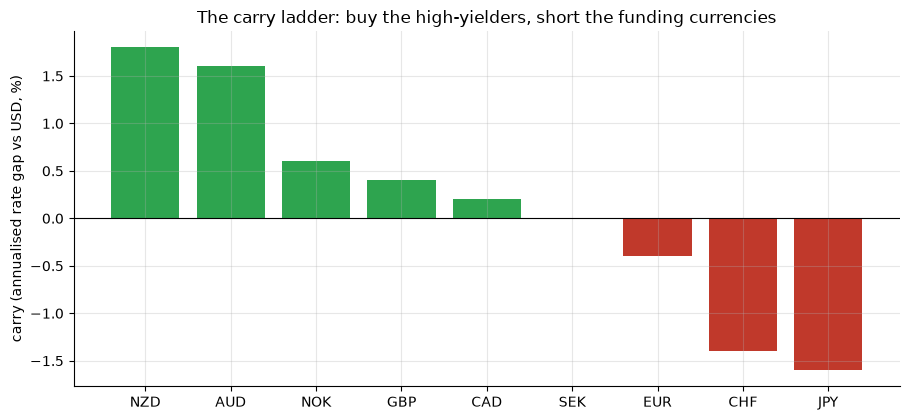

long the top 3: ['NZD', 'AUD', 'NOK']  short the bottom 3: ['EUR', 'CHF', 'JPY']


In [2]:
if HAVE_REAL:
    ranks = st.carry_ranks(B['carry'], B['total_ret'].columns)
    names = list(ranks.index); vals = list(ranks.values)
else:
    names = [c for c,_ in R['carry']]; vals = [v for _,v in R['carry']]
cols = [GREEN if v>0 else RED for v in vals]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(names, vals, color=cols)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('carry (annualised rate gap vs USD, %)')
ax.set_title('The carry ladder: buy the high-yielders, short the funding currencies')
plt.tight_layout(); plt.show()
print('long the top 3:', names[:3], ' short the bottom 3:', names[-3:])

We go **long AUD, NZD, NOK** and **short EUR, JPY, CHF**, dollar-for-dollar (so a falling US dollar doesn't help or hurt us — it's a pure bet on high-yield *beating* low-yield). Now: does it pay?

**The growth of the carry trade.** One dollar of the strategy, compounded month by month. Watch the smooth climb — and the cliffs.

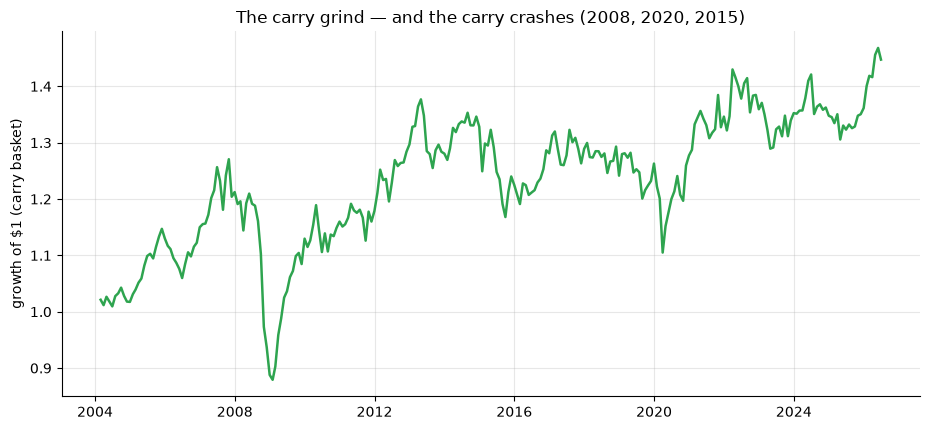

gross premium ~ +2.0%/yr  (Sharpe ~ 0.25)


In [3]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3)
    curve = (1+g).cumprod(); idx = curve.index
else:
    rng = np.random.default_rng(364)
    mu = R['ann_mean']/100/12; sd = mu*np.sqrt(12)/R['sharpe']/np.sqrt(12)
    g = rng.normal(mu, 0.018, R['months']); curve = np.cumprod(1+g)
    import pandas as pd; idx = pd.period_range('2004-01', periods=R['months'], freq='M').to_timestamp('M')
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(idx, np.asarray(curve), c=GREEN, lw=1.8)
ax.set_ylabel('growth of $1 (carry basket)')
ax.set_title('The carry grind — and the carry crashes (2008, 2020, 2015)')
plt.tight_layout(); plt.show()
print(f'gross premium ~ +{R["ann_mean"]:.1f}%/yr  (Sharpe ~ {R["sharpe"]:.2f})')

It climbs — **+2.0%/yr** on average — but look at the **cliffs**: each one is a risk-off panic where the carry trade collapsed. That up-and-then-off-a-cliff shape is the whole story. A smooth grind punctuated by crashes is exactly what selling insurance looks like.

**Calm vs crisis.** Split every month into the calmest 90% and the worst 10%. The difference is brutal — and it's where the 'free lunch' goes to die.

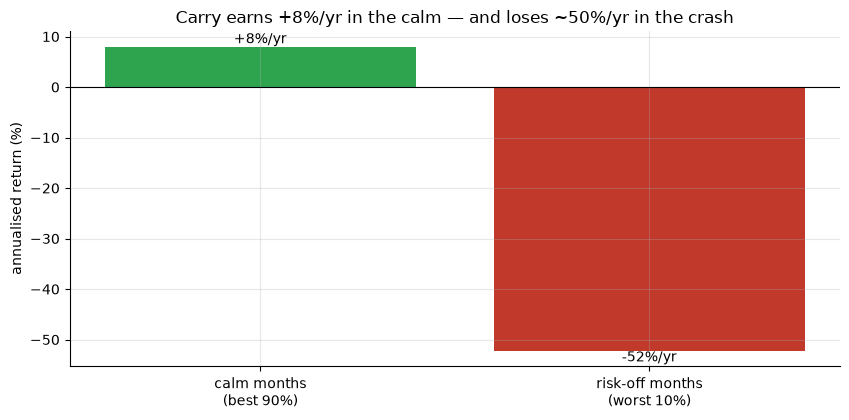

calm: +8%/yr   risk-off: -52%/yr


In [4]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3).values
    cs = st.crash_split(g, q=0.10)
    calm = cs['calm_mean']*12*100; off = cs['off_mean']*12*100
else:
    calm = R['calm_ann']; off = R['off_ann']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['calm months\n(best 90%)', 'risk-off months\n(worst 10%)'], [calm, off],
       color=[GREEN, RED])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised return (%)')
ax.set_title('Carry earns +8%/yr in the calm — and loses ~50%/yr in the crash')
for i,v in enumerate([calm, off]): ax.annotate(f'{v:+.0f}%/yr',(i,v),ha='center',va='bottom' if v>0 else 'top')
plt.tight_layout(); plt.show()
print(f'calm: {calm:+.0f}%/yr   risk-off: {off:+.0f}%/yr')

There it is. In the calm 90% of months carry earns **+8%/yr** — that's the 'free lunch' everyone feels. In the worst 10% it loses **-52%/yr**. The worst single month was **-12%** (2008-10 GFC). The bad months alone hand back **2.7×** everything the strategy ever made. You don't earn the carry; you *rent* it, and the landlord collects in a crash.

## 5 · The verdict

- **Signal — Weak.** The premium is real (**+2.0%/yr**, UIP fails) but small, statistically insignificant on 22 years, and lop-sided (skew **-0.75**, drawdown **-35%**).
- **Tradability — Fragile.** Net of borrowing costs it's barely positive, and it carries a tail that erases years of gains in a single month. Survivable on paper, not a set-and-forget allocation.
- **Free lunch? — Busted.** It's not free — it's a **premium for selling crash insurance**. You collect in the calm and pay it all back, at once, in the panic.

## 6 · Could you actually trade it? — the worst months

Forget the average for a second and just look at the days the carry trade *bit*. Every one of them has a name — and they all happened when the rest of your portfolio was already on fire.

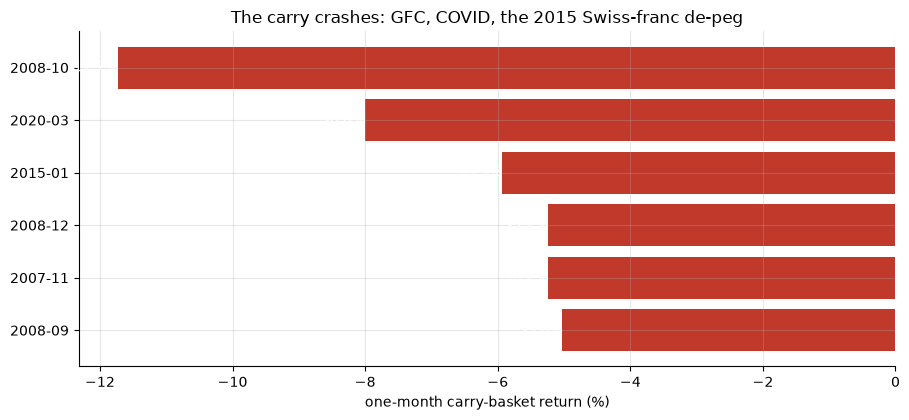

the worst month: 2008-10 -11.7%


In [5]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3)
    worst = g.sort_values().head(6)
    labels = [d.strftime('%Y-%m') for d in worst.index]; vals = list(worst.values*100)
else:
    labels = [w[0] for w in R['worst']]; vals = [w[1] for w in R['worst']]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.barh(range(len(vals)), vals, color=RED)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlabel('one-month carry-basket return (%)')
ax.set_title('The carry crashes: GFC, COVID, the 2015 Swiss-franc de-peg')
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(v,i),ha='right',va='center',color='white')
plt.tight_layout(); plt.show()
print('the worst month:', labels[0], f'{vals[0]:.1f}%')

Around **-12%** in a single month, in the teeth of the 2008 crisis; another **−8%** in the COVID crash; another **−6%** when the Swiss National Bank dropped its franc cap overnight in January 2015. Trading costs barely matter — at a realistic borrow the net premium is still positive. What kills the carry trade as a *strategy* isn't cost, it's **the tail**: a yield that vanishes in a crash, exactly when you can least afford it.

## 7 · Going further 🚪

- **The other FX factor.** [Study 147 — FX-Momentum](../147-fx-momentum/) ranks the same currencies by *trend* instead of *yield* — the two classic currency trades, side by side.
- **Hedge the tail.** Buy cheap out-of-the-money options on the funding currencies to cap the crash — and watch most of the premium disappear, which is the proof that the premium *was* the crash compensation.
- **Time-varying carry.** Swap our fixed rate gaps for live deposit rates and you'll find the carry shrank to almost nothing in the 2010s zero-rate decade — while the crash tail stayed.

*Think the carry is a true free lunch? Show the basket with a **symmetric** return distribution and **no** crash months — then we'll talk.*